<a href="https://colab.research.google.com/github/LCCISNEROS/TALENTO-TECH/blob/main/experiencia/red_neuronal_para_regresion_actividad_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importando una red neuronal para regresion utilizando keras
import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
housing = fetch_california_housing()


In [3]:
# Crear conjuntos de datos de entrenamiento, validación y prueba
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('X_valid:', X_valid.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
print('y_valid:', y_valid.shape)

X_train: (11610, 8)
X_test: (5160, 8)
X_valid: (3870, 8)
y_train: (11610,)
y_test: (5160,)
y_valid: (3870,)


In [5]:
# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_valid = scaler.transform(X_valid)

In [6]:
# Crear el modelo de red neuronal
model = keras.models.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compilar el modelo
model.compile(loss='mean_squared_error',
              optimizer='sgd',
              metrics=[keras.metrics.RootMeanSquaredError(),
                       'mean_absolute_percentage_error'])

In [9]:
# Entrenar el modelo
history = model.fit(X_train, y_train,
                    epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3342 - mean_absolute_percentage_error: 22.7359 - root_mean_squared_error: 0.5780 - val_loss: 0.3340 - val_mean_absolute_percentage_error: 23.6858 - val_root_mean_squared_error: 0.5779
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3355 - mean_absolute_percentage_error: 23.2168 - root_mean_squared_error: 0.5790 - val_loss: 0.3341 - val_mean_absolute_percentage_error: 22.2258 - val_root_mean_squared_error: 0.5780
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3351 - mean_absolute_percentage_error: 22.6532 - root_mean_squared_error: 0.5789 - val_loss: 0.3349 - val_mean_absolute_percentage_error: 24.4858 - val_root_mean_squared_error: 0.5787
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3372 - mean_absolute_percentage_error: 22.7569 - root_mean_squared_error: 0.5806 - val_loss: 0.3326 - val_mean_absolute_percentage_error: 23.0331 - val_root_mean_squared_error: 0.5767
Epoch 5/20
363/3

<Axes: >

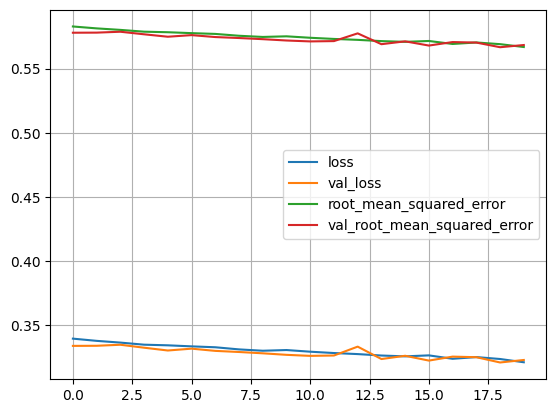

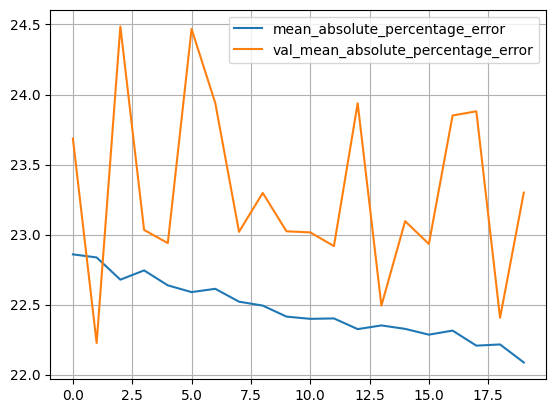

In [10]:
# Graficar el historial de entrenamiento:
dfHistory = pd.DataFrame(history.history)

dfHistory[['loss', 'val_loss', 'root_mean_squared_error',
           'val_root_mean_squared_error']].plot(grid=True)

dfHistory[['mean_absolute_percentage_error',
           'val_mean_absolute_percentage_error']].plot(grid=True)


In [11]:
# Evaluar el modelo en el conjunto de entrenamiento
loss, RMSE, MAPE = model.evaluate(X_train, y_train)
print("Evaluar el modelo en el conjunto de entrenamiento")
print("loss train:", loss)
print("root_mean_squared_error train:", RMSE)
print("mean_absolute_percentage_error train:", MAPE)

# Evaluar el modelo en el conjunto de validación
loss, RMSE, MAPE = model.evaluate(X_valid, y_valid)
print("Evaluar el modelo en el conjunto de validación")
print("loss valid:", loss)
print("root_mean_squared_error valid:", RMSE)
print("mean_absolute_percentage_error valid:", MAPE)

# Evaluar el modelo en el conjunto de prueba
loss, RMSE, MAPE = model.evaluate(X_test, y_test)
print("Evaluar el modelo en el conjunto de prueba")
print("loss test:", loss)
print("root_mean_squared_error test:", RMSE)
print("mean_absolute_percentage_error test:", MAPE)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3197 - mean_absolute_percentage_error: 22.5785 - root_mean_squared_error: 0.5653
Evaluar el modelo en el conjunto de entrenamiento
loss train: 0.31969839334487915
root_mean_squared_error train: 0.5654187798500061
mean_absolute_percentage_error train: 22.48973274230957
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3008 - mean_absolute_percentage_error: 22.9896 - root_mean_squared_error: 0.5479
Evaluar el modelo en el conjunto de validación
loss valid: 0.32304200530052185
root_mean_squared_error valid: 0.5683678388595581
mean_absolute_percentage_error valid: 23.299495697021484
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3345 - mean_absolute_percentage_error: 23.1148 - root_mean_squared_error: 0.5783
Evaluar el modelo en el conjunto de prueba
loss test: 0.3397487998008728
root_mean_squared_error test: 0.5828797817230225
mean_absolute_percentage_error test: 23.135160446166992
